# 🚀 Proyecto NLP – Detección de discurso de odio en comentarios de YouTube  

## 🎯 Objetivo del notebook  
Este cuaderno realiza el **Análisis Exploratorio de Datos (EDA)** y el **preprocesamiento completo**  
del dataset `youtoxic_english_1000.csv`, que contiene comentarios de vídeos de YouTube  
etiquetados con diferentes categorías de toxicidad.  

Nuestra meta es preparar los datos para entrenar un modelo de clasificación binaria  
que detecte **discurso de odio (`IsToxic`)**.  

## 📋 Flujo de trabajo  
1. Carga e inspección del dataset
2. Distribución de `IsToxic` y de todas las etiquetas booleanas
3. Correlaciones entre etiquetas
4. Co-ocurrencia: ¿qué otras etiquetas acompañan a `IsToxic`?
5. Análisis de longitud de texto por clase
6. Nubes de palabras por clase
7. Top N-gramas por clase
8. Conclusiones del EDA

> 🔧 **Stack tecnológico:** `uv` como gestor de paquetes, `pandas`, `numpy`, `matplotlib`, `seaborn`,  
> `nltk`, `wordcloud`, `spaCy`, `scikit-learn`, `nlpaug`.  

In [2]:
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
TARGET = 'IsToxic'

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 🛠️ 0. Entorno y dependencias
Ejecutar una sola vez. Instala librerías y descarga recursos de NLTK.

## 📓 1. Carga del dataset e inspección básica

El dataset contiene **1 000 comentarios de YouTube** con 12 etiquetas booleanas de toxicidad.  
Nuestra variable objetivo es **`IsToxic`**: indica si el comentario es tóxico en sentido general.

| Columna | Descripción |
|---|---|
| `Text` | Texto del comentario |
| `IsToxic` | ⬅️ **Target**: tóxico en sentido general |
| `IsAbusive` | Lenguaje abusivo |
| `IsThreat` | Amenaza directa |
| `IsProvocative` | Provocador |
| `IsObscene` | Obsceno |
| `IsHatespeech` | Discurso de odio |
| `IsRacist` | Racismo |
| `IsNationalist` | Nacionalismo |
| `IsSexist` | Sexismo |
| `IsHomophobic` | Homofobia |
| `IsReligiousHate` | Odio religioso |
| `IsRadicalism` | Radicalismo |

In [3]:
df = pd.read_csv('../data/raw/youtoxic_english_1000.csv')

print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nTipos:\n', df.dtypes)
print('\nNulos:\n', df.isnull().sum())
df.head()

Shape: (1000, 15)

Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

Tipos:
 CommentId          object
VideoId            object
Text               object
IsToxic              bool
IsAbusive            bool
IsThreat             bool
IsProvocative        bool
IsObscene            bool
IsHatespeech         bool
IsRacist             bool
IsNationalist        bool
IsSexist             bool
IsHomophobic         bool
IsReligiousHate      bool
IsRadicalism         bool
dtype: object

Nulos:
 CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


## 📊 2. Distribución de la variable objetivo `IsToxic`

Analizamos el balance de clases, que determinará si necesitaremos técnicas de reequilibrio
en el preprocesamiento.

C:\Users\bruno\AppData\Local\Temp\ipykernel_37044\1964070090.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET, data=df, palette=['steelblue', 'tomato'], ax=axes[0])


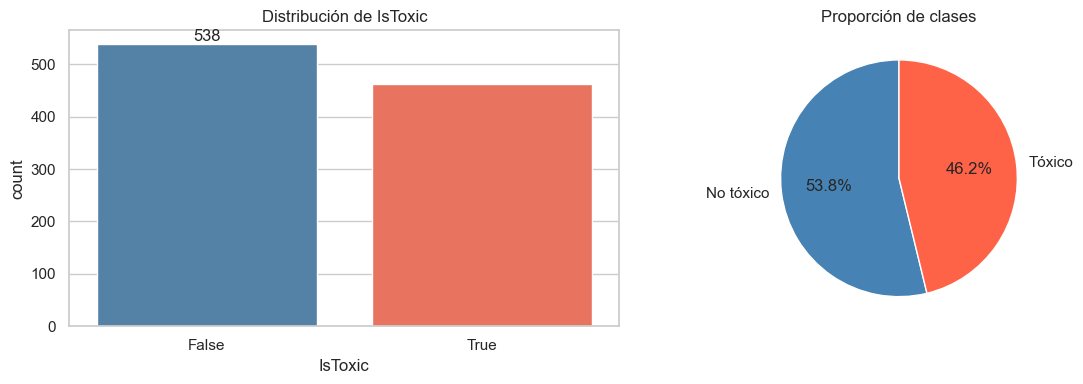

Conteo absoluto:
 IsToxic
False    538
True     462
Name: count, dtype: int64

Proporción:
 IsToxic
False    0.538
True     0.462
Name: proportion, dtype: float64


In [4]:
counts      = df[TARGET].value_counts()
proportions = df[TARGET].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Countplot
sns.countplot(x=TARGET, data=df, palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Distribución de IsToxic')
axes[0].bar_label(axes[0].containers[0])

# Pie chart
axes[1].pie(counts, labels=['No tóxico', 'Tóxico'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print('Conteo absoluto:\n', counts)
print('\nProporción:\n', proportions.round(3))

## 📊 3. Distribución de todas las etiquetas booleanas

Comparamos la prevalencia de cada tipo de toxicidad para entender el contexto del dataset
y la relación de `IsToxic` con las categorías más específicas.

C:\Users\bruno\AppData\Local\Temp\ipykernel_37044\2048667467.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=positives.index, y=positives.values, palette='RdYlGn_r')


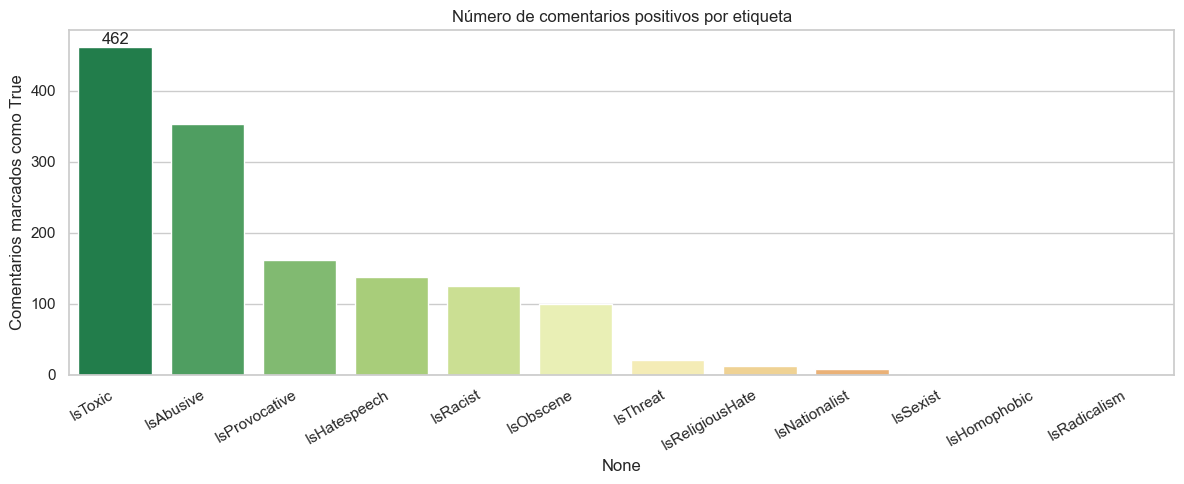

IsToxic            462
IsAbusive          353
IsProvocative      161
IsHatespeech       138
IsRacist           125
IsObscene          100
IsThreat            21
IsReligiousHate     12
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsRadicalism         0
dtype: int64


In [5]:
bool_cols = [c for c in df.columns if c.startswith('Is')]

positives = df[bool_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ax = sns.barplot(x=positives.index, y=positives.values, palette='RdYlGn_r')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=30, ha='right')
plt.title('Número de comentarios positivos por etiqueta')
plt.ylabel('Comentarios marcados como True')
plt.tight_layout()
plt.show()

print(positives)

## 🔗 4. Correlación entre etiquetas booleanas

Un heatmap de correlación de Pearson entre todas las flags booleanas revela qué tipos
de toxicidad tienden a coexistir en un mismo comentario.

> **Lectura del heatmap:** valores cercanos a 1 indican que ambas etiquetas aparecen juntas
> frecuentemente; cercanos a 0, que son independientes.

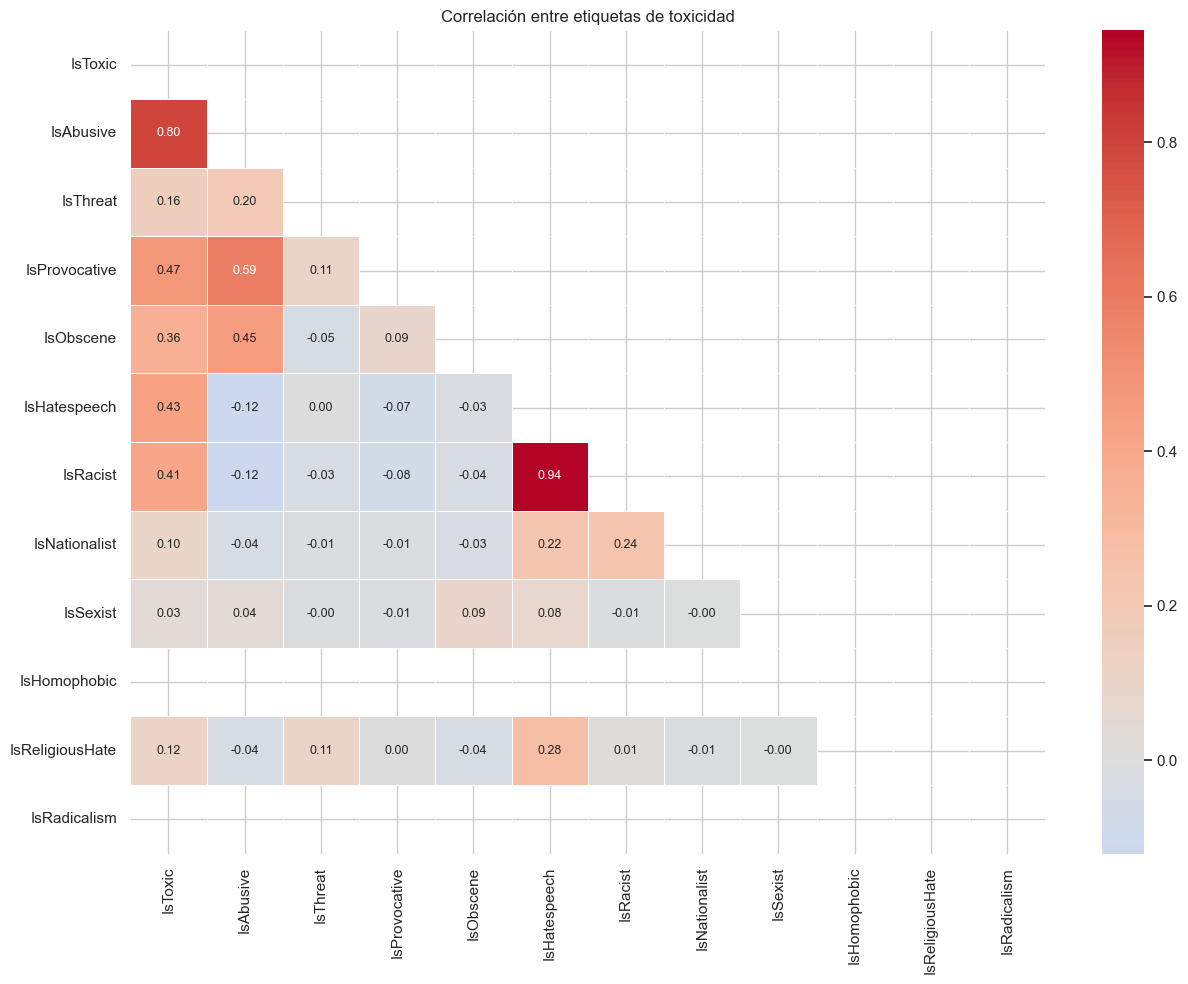

In [7]:
corr = df[bool_cols].astype(int).corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlación entre etiquetas de toxicidad')
plt.tight_layout()
plt.show()

## 🔀 5. Co-ocurrencia: ¿qué acompaña a `IsToxic`?

De los comentarios marcados como tóxicos, ¿cuántos también están marcados como abusivos,
amenazantes, obscenos, etc.?  
Esto nos dice cuánto solapamiento hay entre `IsToxic` y las categorías más específicas,
y si `IsToxic` es efectivamente la etiqueta más general del dataset.

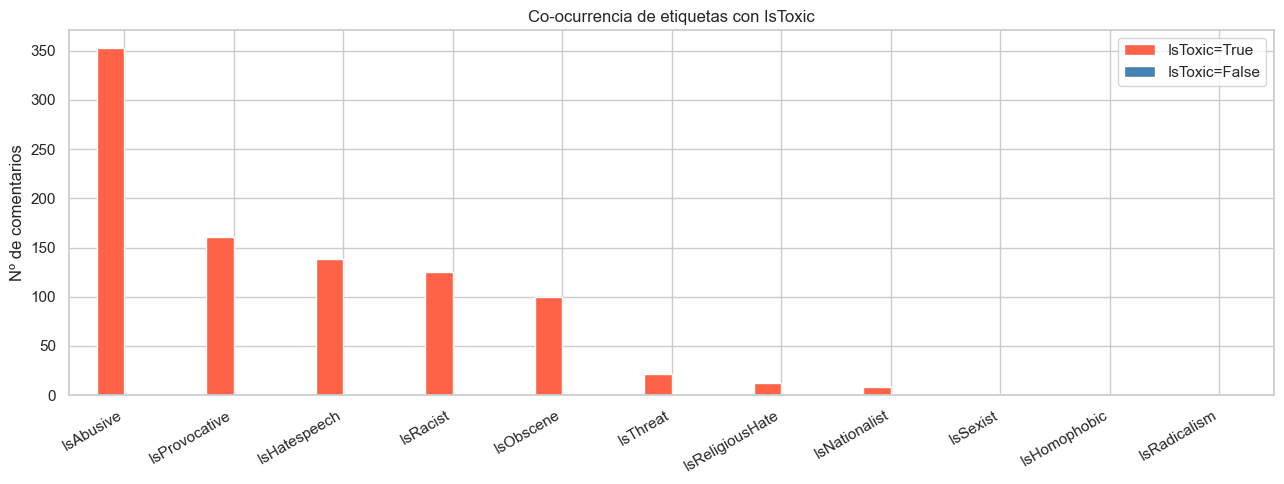


Porcentaje sobre los tóxicos:
IsAbusive          76.4
IsProvocative      34.8
IsHatespeech       29.9
IsRacist           27.1
IsObscene          21.6
IsThreat            4.5
IsReligiousHate     2.6
IsNationalist       1.7
IsSexist            0.2
IsHomophobic        0.0
IsRadicalism        0.0
Name: IsToxic=True, dtype: float64


In [8]:
# commit: "feat: analyze label co-occurrence with IsToxic target (#5, #1)"
toxic_df   = df[df[TARGET] == True]
notoxic_df = df[df[TARGET] == False]

other_labels = [c for c in bool_cols if c != TARGET]

cooc_toxic   = toxic_df[other_labels].sum()
cooc_notoxic = notoxic_df[other_labels].sum()

cooc = pd.DataFrame({
    'IsToxic=True':  cooc_toxic.values,
    'IsToxic=False': cooc_notoxic.values
}, index=other_labels).sort_values('IsToxic=True', ascending=False)

cooc.plot(kind='bar', figsize=(13, 5), color=['tomato', 'steelblue'])
plt.title('Co-ocurrencia de etiquetas con IsToxic')
plt.ylabel('Nº de comentarios')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print('\nPorcentaje sobre los tóxicos:')
print((cooc['IsToxic=True'] / len(toxic_df) * 100).round(1))

## 📏 6. Longitud de texto por clase (`IsToxic`)

Calculamos `text_length` (caracteres) y `word_count` (palabras) para cada comentario
y comparamos su distribución entre clases.

Una diferencia significativa de longitud entre clases puede ser una señal predictiva
útil, y también nos ayuda a detectar outliers que podrían afectar al vectorizador.

=== Estadísticas por clase ===
        text_length                                                word_count  \
              count   mean    std  min   25%    50%    75%     max      count   
IsToxic                                                                         
False         538.0  182.3  252.3  3.0  44.0   96.0  210.8  2292.0      538.0   
True          462.0  189.4  291.1  6.0  54.2  110.0  220.8  4421.0      462.0   

                                                   
         mean   std  min   25%   50%   75%    max  
IsToxic                                            
False    33.1  45.2  1.0   8.0  18.0  38.0  418.0  
True     34.6  53.3  1.0  10.0  20.0  40.0  815.0  


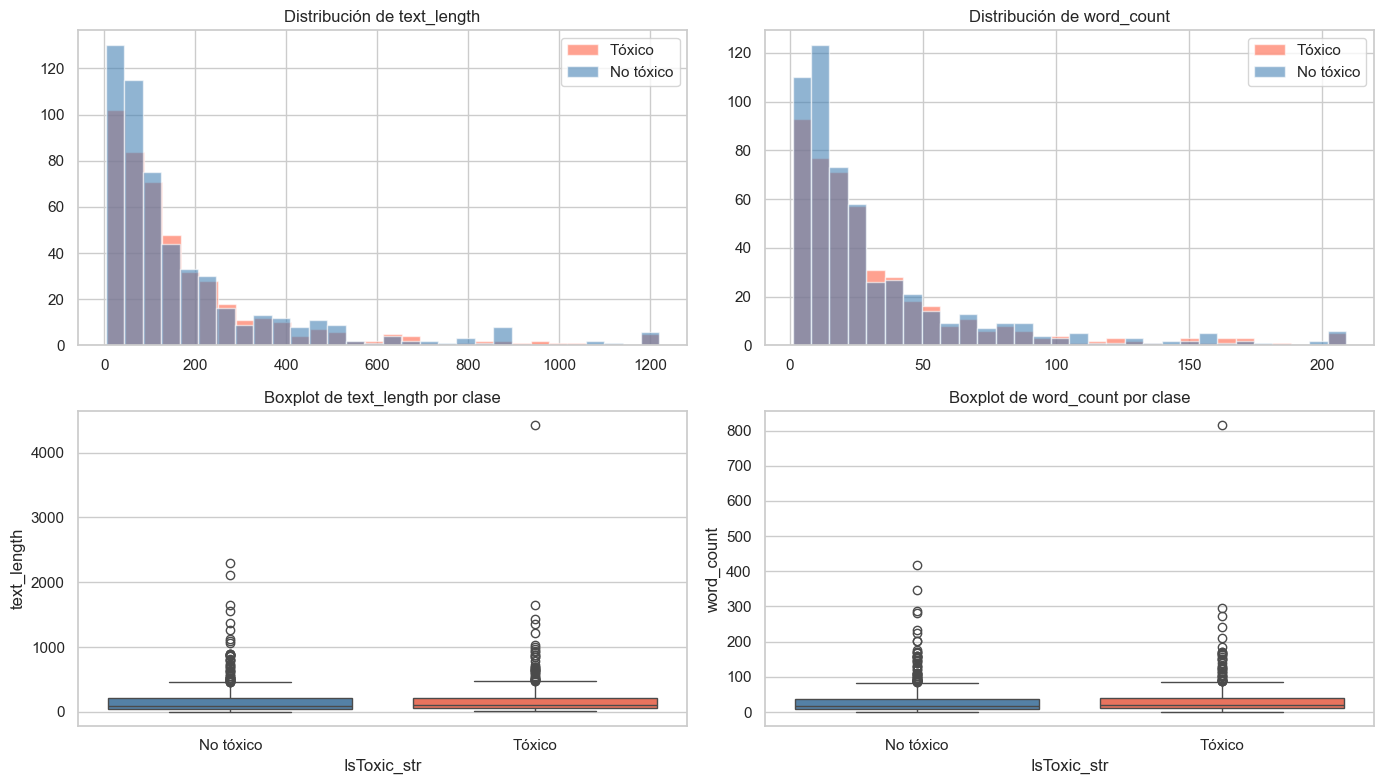

In [10]:
# commit: "feat: compare text length distribution between IsToxic classes (#5, #1)"
df['text_length'] = df['Text'].astype(str).apply(len)
df['word_count']  = df['Text'].astype(str).apply(lambda x: len(x.split()))

print('=== Estadísticas por clase ===')
print(df.groupby(TARGET)[['text_length', 'word_count']].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# FIX: trabajar con strings para que el palette case correctamente
df['IsToxic_str'] = df[TARGET].map({True: 'Tóxico', False: 'No tóxico'})
palette = {'Tóxico': 'tomato', 'No tóxico': 'steelblue'}

for i, col in enumerate(['text_length', 'word_count']):
    # Histograma solapado
    for val, color, label in [(True, 'tomato', 'Tóxico'),
                               (False, 'steelblue', 'No tóxico')]:
        axes[0, i].hist(df[df[TARGET] == val][col].clip(upper=df[col].quantile(0.99)),
                        bins=30, alpha=0.6, color=color, label=label)
    axes[0, i].set_title(f'Distribución de {col}')
    axes[0, i].legend()

    # FIX: usar hue en vez de x para el palette, y legend=False para no duplicar leyenda
    sns.boxplot(data=df, x='IsToxic_str', y=col,
                hue='IsToxic_str', palette=palette,
                legend=False, ax=axes[1, i])
    axes[1, i].set_title(f'Boxplot de {col} por clase')

plt.tight_layout()
plt.show()

# Limpiar columna auxiliar
df.drop(columns=['IsToxic_str'], inplace=True)

## ☁️ 7. Nubes de palabras por clase

Visualizamos las palabras más frecuentes (excluidas stopwords) en cada clase.  
Las diferencias de vocabulario entre nubes son el indicador cualitativo más directo
del poder discriminativo del texto para nuestro clasificador.

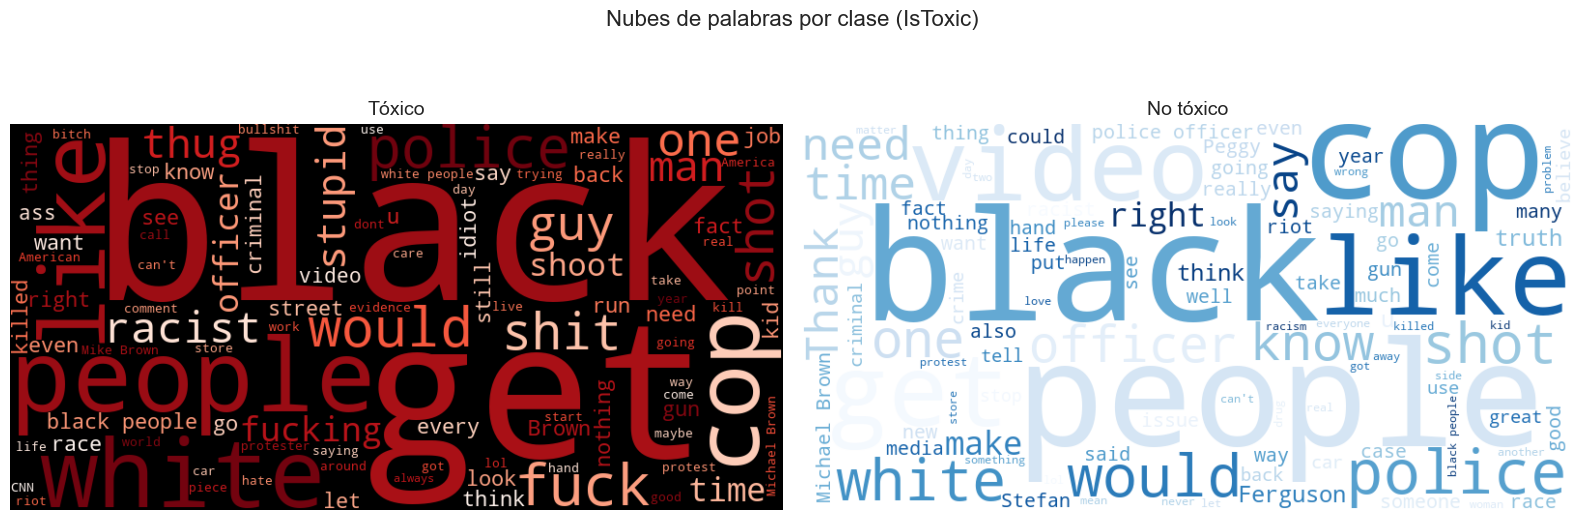

In [11]:
stop_words = set(stopwords.words('english'))

toxic_text   = ' '.join(df[df[TARGET] == True]['Text'].astype(str))
notoxic_text = ' '.join(df[df[TARGET] == False]['Text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, text, title, bg, cmap in [
    (axes[0], toxic_text,   'Tóxico',     'black', 'Reds'),
    (axes[1], notoxic_text, 'No tóxico',  'white', 'Blues'),
]:
    wc = WordCloud(stopwords=stop_words, background_color=bg,
                   colormap=cmap, width=800, height=400,
                   max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.suptitle('Nubes de palabras por clase (IsToxic)', fontsize=16)
plt.tight_layout()
plt.show()

## 📈 8. Top N-gramas por clase

Extraemos los 15 unigramas y bigramas más frecuentes en cada clase usando `CountVectorizer`.  
Los bigramas capturan patrones de dos palabras que los unigramas no pueden detectar
(p. ej., "fuck you", "white people", "go back").

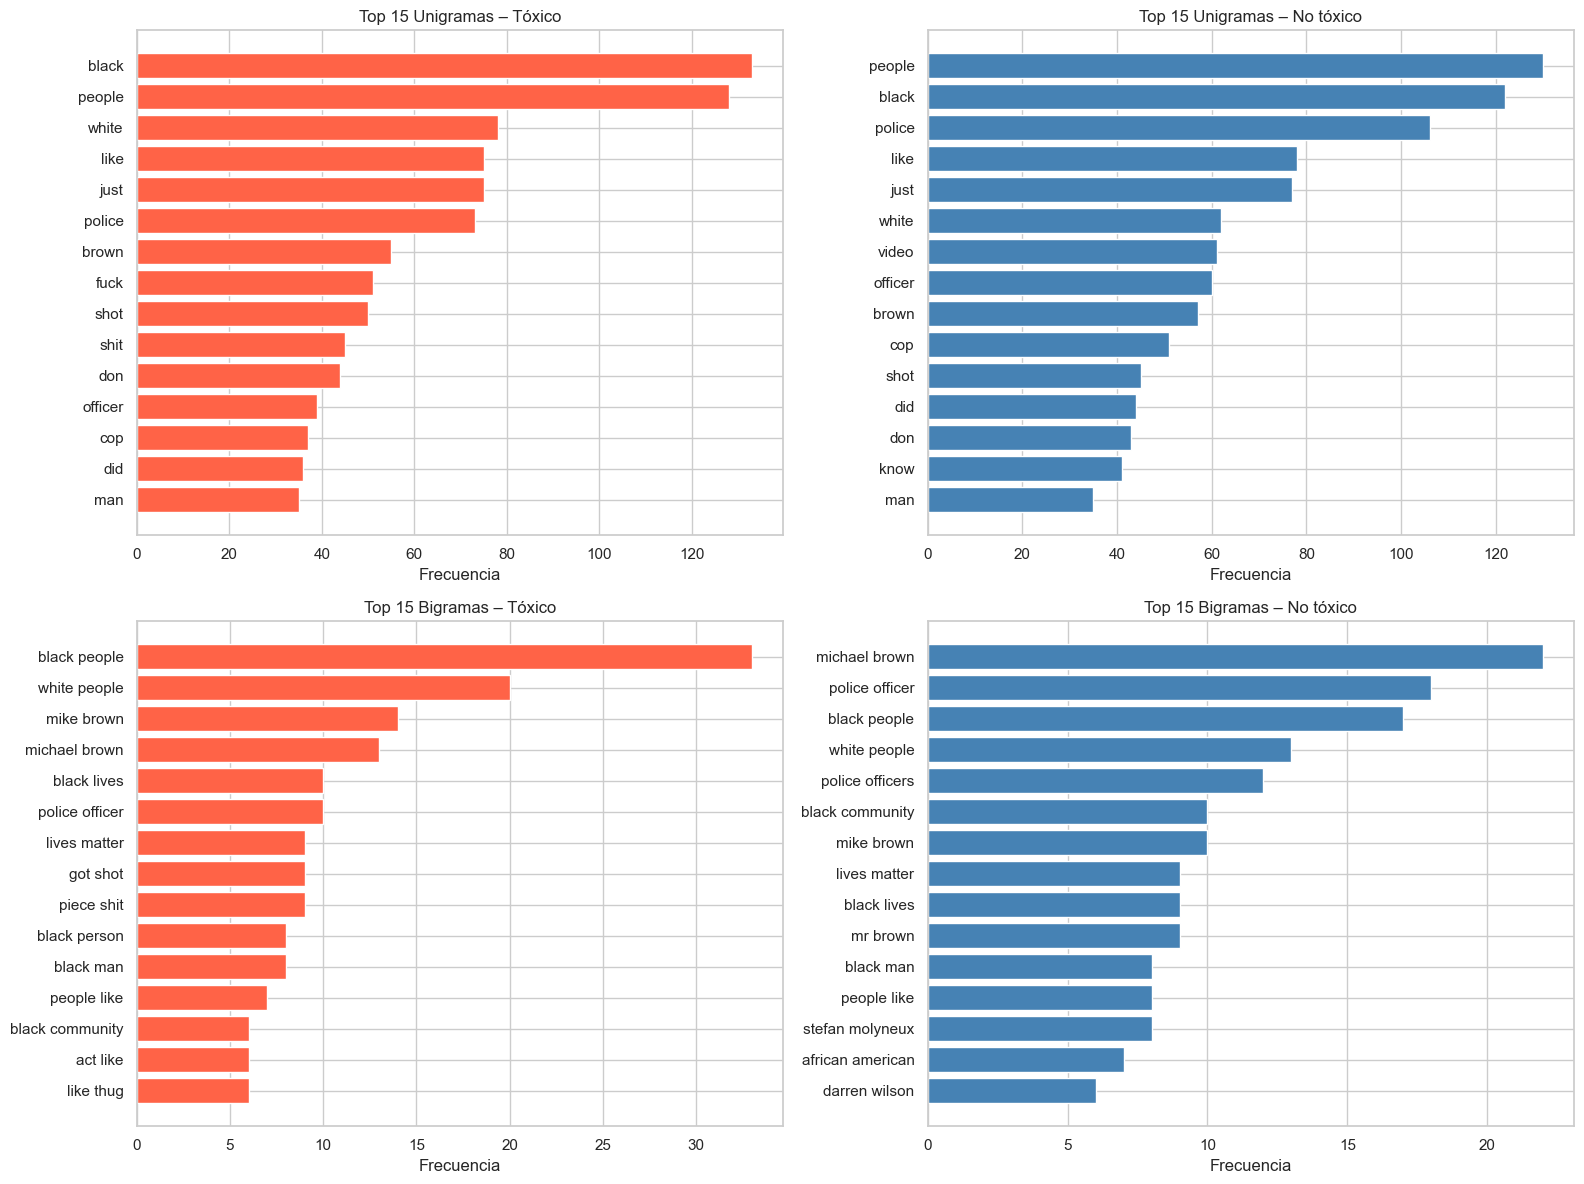

In [12]:
def top_ngrams(corpus, n=1, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english',
                          max_features=10000).fit(corpus)
    bag = vec.transform(corpus)
    freqs = bag.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(freqs, index=words).sort_values(ascending=False).head(top_k)

toxic_corpus   = df[df[TARGET] == True]['Text'].astype(str)
notoxic_corpus = df[df[TARGET] == False]['Text'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, n, label in [(0, 1, 'Unigramas'), (1, 2, 'Bigramas')]:
    for col, (corpus, title, color) in enumerate([
        (toxic_corpus,   'Tóxico',    'tomato'),
        (notoxic_corpus, 'No tóxico', 'steelblue'),
    ]):
        data = top_ngrams(corpus, n=n)
        axes[row, col].barh(data.index[::-1], data.values[::-1], color=color)
        axes[row, col].set_title(f'Top 15 {label} – {title}')
        axes[row, col].set_xlabel('Frecuencia')

plt.tight_layout()
plt.show()